# 📚 Système Juridique Intelligent Marocain
## Notebook 01 — Prétraitement NLP des données juridiques

---

Ce notebook couvre :
1. Chargement et exploration des données
2. Analyse statistique
3. Extraction de texte des PDFs
4. Nettoyage et prétraitement NLP
5. Tokenization & Lemmatisation
6. Détection de langue
7. Extraction des métadonnées juridiques
8. Visualisations
9. Export des données traitées

In [16]:
# ============================================================
#  CELLULE 1 — Installation des dépendances
# ============================================================
import subprocess, sys

packages = [
    'pandas', 'numpy', 'matplotlib', 'seaborn',
    'scikit-learn', 'nltk', 'langdetect',
    'pymupdf', 'python-docx', 'pytesseract',
    'wordcloud', 'regex'
]

for pkg in packages:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q',
                    '--break-system-packages'], capture_output=True)

print('✅ Dépendances installées')

✅ Dépendances installées


In [17]:
# ============================================================
#  CELLULE 2 — Imports
# ============================================================
import os, re, json, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

# Répertoires
DATA_DIR     = '../data'
PROC_DIR     = '../processed_data'
os.makedirs(PROC_DIR, exist_ok=True)

print('✅ Imports réussis')
print(f'   Pandas  : {pd.__version__}')
print(f'   NumPy   : {np.__version__}')

✅ Imports réussis
   Pandas  : 2.2.2
   NumPy   : 1.26.4


---
## 1. Chargement et exploration des données

In [18]:
# ============================================================
#  CELLULE 3 — Chargement du CSV brut
# ============================================================
df = pd.read_csv(os.path.join(DATA_DIR, 'raw_laws.csv'))

print('=' * 60)
print('APERÇU DES DONNÉES')
print('=' * 60)
print(f'Lignes    : {len(df)}')
print(f'Colonnes  : {df.columns.tolist()}')
print()
print(df.head(3).to_string())

APERÇU DES DONNÉES
Lignes    : 45
Colonnes  : ['id', 'source_file', 'category', 'subcategory', 'law_number', 'title', 'article_number', 'article_text', 'language', 'date_promulgation']

   id                           source_file category subcategory  law_number                                 title  article_number                                                                                                                                                                     article_text language date_promulgation
0   1  Code_des_Obligations_et_des_Contrats    civil    contrats  DOC-12-101  Code des Obligations et des Contrats               1                                                  Les obligations dérivent des conventions et autres déclarations de volonté, des quasi-contrats, des délits et des quasi-délits.       fr        1913-08-12
1   2  Code_des_Obligations_et_des_Contrats    civil    contrats  DOC-12-101  Code des Obligations et des Contrats               2              

In [19]:
# ============================================================
#  CELLULE 4 — Statistiques descriptives
# ============================================================
print('📊 Statistiques descriptives\n')

print(f"Articles par catégorie :")
print(df['category'].value_counts().to_string())
print()
print(f"Langues :")
print(df['language'].value_counts().to_string())
print()
print(f"Lois distinctes : {df['law_number'].nunique()}")
print(f"Sources distinctes : {df['source_file'].nunique()}")
print()
print('Valeurs manquantes :')
print(df.isnull().sum().to_string())

📊 Statistiques descriptives

Articles par catégorie :
category
civil        12
penal        11
familial      9
social        8
education     5

Langues :
language
fr    43
ar     2

Lois distinctes : 13
Sources distinctes : 14

Valeurs manquantes :
id                   0
source_file          0
category             0
subcategory          0
law_number           0
title                0
article_number       0
article_text         0
language             0
date_promulgation    0


In [20]:
# ============================================================
#  CELLULE 5 — Extraction de texte depuis les PDFs (PyMuPDF + OCR)
# ============================================================
import fitz  # PyMuPDF

PDF_DIR = '../data'  # Les PDFs sont placés ici

def extract_text_from_pdf(pdf_path: str) -> str:
    """Extrait le texte d'un PDF. Tente la méthode digitale,
    puis bascule sur OCR si le PDF est scanné."""
    text = ''
    try:
        doc = fitz.open(pdf_path)
        for page in doc:
            page_text = page.get_text('text')
            text += page_text
    except Exception as e:
        print(f'  ⚠️  {os.path.basename(pdf_path)}: {e}')
        return ''

    # Si le texte est vide → PDF scanné → OCR
    if len(text.strip()) < 50:
        try:
            import pytesseract
            from PIL import Image
            doc = fitz.open(pdf_path)
            ocr_text = ''
            for page in doc:
                pix = page.get_pixmap(dpi=200)
                img = Image.frombytes('RGB', [pix.width, pix.height], pix.samples)
                # Langues : français + arabe
                page_ocr = pytesseract.image_to_string(img, lang='fra+ara')
                ocr_text += page_ocr + '\n'
            text = ocr_text
        except Exception as ocr_err:
            print(f'  ⚠️  OCR échoué pour {os.path.basename(pdf_path)}: {ocr_err}')
    return text


def extract_articles_from_text(text: str, source: str, category: str) -> list:
    """Segmente un texte juridique en articles.
    Reconnaît les patterns : Article N°, المادة N"""
    articles = []

    # Pattern français : Article 1, Art. 2, ARTICLE 3
    pattern_fr = r'(?:Article|Art\.|ARTICLE)\s+(\d+)\s*[:\-–]?\s*([^\n(?:Article|Art\.|ARTICLE)]*?)(?=(?:Article|Art\.|ARTICLE)\s+\d+|$)'
    for m in re.finditer(pattern_fr, text, re.DOTALL | re.IGNORECASE):
        art_num = m.group(1)
        art_text = m.group(2).strip()
        if len(art_text) > 20:
            articles.append({
                'source_file': source,
                'category': category,
                'article_number': art_num,
                'article_text': art_text[:2000],
                'language': 'fr'
            })

    # Pattern arabe : المادة 1
    pattern_ar = r'المادة\s+(\d+)\s*[:\-]?\s*([^المادة]*?)(?=المادة\s+\d+|$)'
    for m in re.finditer(pattern_ar, text, re.DOTALL):
        art_num = m.group(1)
        art_text = m.group(2).strip()
        if len(art_text) > 20:
            articles.append({
                'source_file': source,
                'category': category,
                'article_number': art_num,
                'article_text': art_text[:2000],
                'language': 'ar'
            })

    return articles


print('✅ Fonctions d\'extraction définies')
print('   → extract_text_from_pdf(path)')
print('   → extract_articles_from_text(text, source, category)')

✅ Fonctions d'extraction définies
   → extract_text_from_pdf(path)
   → extract_articles_from_text(text, source, category)


---
## 2. Prétraitement NLP

In [21]:
# ============================================================
#  CELLULE 6 — Fonctions de nettoyage NLP
# ============================================================

# --- Stopwords juridiques français ---
STOPWORDS_FR = {
    'le','la','les','de','du','des','un','une','et','en','à','au','aux',
    'est','sont','sera','ont','par','pour','sur','dans','avec','qui',
    'que','qu','il','elle','ils','elles','se','si','ou','ni','ne','pas',
    'plus','tout','toute','tous','toutes','cette','cet','ces','leur','leurs',
    'être','avoir','faire','dit','doit','peut','même'
}

# --- Stopwords juridiques arabes ---
STOPWORDS_AR = {
    'من','إلى','على','في','أن','عن','مع','هذا','هذه','ذلك','التي','الذي',
    'هو','هي','كان','كانت','يكون','تكون','وأن','أو','أي','كل','بعض',
    'لا','لم','لن','قد','قال','يجب','يجوز'
}


def normalize_arabic(text: str) -> str:
    """Normalise le texte arabe :
    - Supprime les diacritiques (tashkeel)
    - Normalise les variantes de alef
    - Supprime les caractères spéciaux non-arabes"""
    # Supprimer les diacritiques
    text = re.sub(r'[\u064B-\u065F\u0670]', '', text)
    # Normaliser alef
    text = re.sub(r'[أإآ]', 'ا', text)
    # Normaliser teh marbuta
    text = re.sub(r'ة', 'ه', text)
    # Normaliser ya
    text = re.sub(r'ى', 'ي', text)
    return text


def clean_legal_text(text: str, lang: str = 'fr') -> str:
    """Nettoyage complet d'un texte juridique :
    1. Normalisation Unicode
    2. Suppression des caractères indésirables
    3. Gestion des espaces multiples
    4. Normalisation arabe si nécessaire"""
    if not isinstance(text, str) or len(text.strip()) == 0:
        return ''

    # Remplacer les caractères de contrôle et retours chariot
    text = re.sub(r'[\x00-\x08\x0B\x0C\x0E-\x1F\x7F]', ' ', text)
    text = text.replace('\r\n', '\n').replace('\r', '\n')

    # Supprimer les numéros de page isolés
    text = re.sub(r'^\s*\d+\s*$', '', text, flags=re.MULTILINE)

    # Supprimer les séquences de tirets ou underscores (séparateurs)
    text = re.sub(r'[-_]{3,}', ' ', text)

    if lang == 'ar':
        text = normalize_arabic(text)

    # Normaliser les espaces
    text = re.sub(r'[ \t]+', ' ', text)
    text = re.sub(r'\n{3,}', '\n\n', text)

    return text.strip()


def detect_language(text: str) -> str:
    """Détecte la langue du texte.
    - Retourne 'ar' si le texte contient plus de 30% de caractères arabes
    - Sinon utilise langdetect
    - Défaut : 'fr'"""
    if not text:
        return 'fr'

    # Compter les caractères arabes
    arabic_chars = len(re.findall(r'[\u0600-\u06FF]', text))
    total_alpha = len(re.findall(r'[a-zA-Z\u0600-\u06FF]', text))

    if total_alpha > 0 and arabic_chars / total_alpha > 0.30:
        return 'ar'

    try:
        from langdetect import detect
        return detect(text)
    except Exception:
        return 'fr'


def simple_tokenize(text: str, lang: str = 'fr') -> list:
    """Tokenisation simple par mots.
    Pour l'arabe : segmentation sur les espaces.
    Pour le français : segmentation sur les mots alphanumériques."""
    if lang == 'ar':
        return text.split()
    return re.findall(r'\b[a-zA-ZÀ-ÿ0-9]{2,}\b', text.lower())


def remove_stopwords(tokens: list, lang: str = 'fr') -> list:
    """Supprime les mots vides selon la langue."""
    sw = STOPWORDS_AR if lang == 'ar' else STOPWORDS_FR
    return [t for t in tokens if t.lower() not in sw]


def extract_legal_metadata(text: str, lang: str = 'fr') -> dict:
    """Extrait les métadonnées juridiques d'un texte :
    - numéros d'articles
    - références à d'autres lois
    - amendes et peines"""
    metadata = {
        'has_penalty': False,
        'has_fine': False,
        'referenced_articles': [],
        'keywords': []
    }

    if lang == 'fr':
        # Détecter les peines
        if re.search(r'emprisonnement|prison|détention|réclusion', text, re.I):
            metadata['has_penalty'] = True
        # Détecter les amendes
        if re.search(r'amende|dirham|dh|sanction pécuniaire', text, re.I):
            metadata['has_fine'] = True
        # Articles référencés
        metadata['referenced_articles'] = re.findall(
            r'article\s+(\d+)', text, re.I
        )
        # Mots-clés juridiques
        kw_patterns = {
            'contrat': r'contrat|convention|accord',
            'responsabilite': r'responsabilit[eé]|faut[e]?',
            'propriete': r'propriét[eé]|possession|bien',
            'tribunal': r'tribunal|juge|juridiction|cour',
            'droit': r'\bdroit\b|\bobligation\b',
            'travail': r'travail|salarié|employeur|licenciement',
            'famille': r'mariage|divorce|garde|tutelle',
            'penal': r'infraction|délit|crime|peine'
        }
        for kw, pat in kw_patterns.items():
            if re.search(pat, text, re.I):
                metadata['keywords'].append(kw)
    else:  # arabe
        if re.search(r'سجن|حبس|اعتقال', text):
            metadata['has_penalty'] = True
        if re.search(r'غرامة|درهم', text):
            metadata['has_fine'] = True

    return metadata


print('✅ Fonctions NLP définies :')
print('   → normalize_arabic(text)')
print('   → clean_legal_text(text, lang)')
print('   → detect_language(text)')
print('   → simple_tokenize(text, lang)')
print('   → remove_stopwords(tokens, lang)')
print('   → extract_legal_metadata(text, lang)')

✅ Fonctions NLP définies :
   → normalize_arabic(text)
   → clean_legal_text(text, lang)
   → detect_language(text)
   → simple_tokenize(text, lang)
   → remove_stopwords(tokens, lang)
   → extract_legal_metadata(text, lang)


In [22]:
# ============================================================
#  CELLULE 7 — Application du pipeline NLP sur le jeu de données
# ============================================================
print('⚙️  Application du pipeline NLP...\n')

df_proc = df.copy()

# 1. Détection de langue
df_proc['lang_detected'] = df_proc.apply(
    lambda r: detect_language(str(r['article_text'])), axis=1
)

# 2. Nettoyage du texte
df_proc['article_text_clean'] = df_proc.apply(
    lambda r: clean_legal_text(str(r['article_text']), r['lang_detected']), axis=1
)

# 3. Longueur du texte
df_proc['text_length'] = df_proc['article_text_clean'].str.len()
df_proc['word_count']  = df_proc['article_text_clean'].apply(
    lambda t: len(t.split())
)

# 4. Tokenisation et suppression des stopwords
df_proc['tokens'] = df_proc.apply(
    lambda r: simple_tokenize(r['article_text_clean'], r['lang_detected']), axis=1
)
df_proc['tokens_no_sw'] = df_proc.apply(
    lambda r: remove_stopwords(r['tokens'], r['lang_detected']), axis=1
)
df_proc['token_count']  = df_proc['tokens'].apply(len)
df_proc['content_token_count'] = df_proc['tokens_no_sw'].apply(len)

# 5. Extraction des métadonnées
meta = df_proc.apply(
    lambda r: extract_legal_metadata(r['article_text_clean'], r['lang_detected']), axis=1
)
df_proc['has_penalty']          = meta.apply(lambda m: m['has_penalty'])
df_proc['has_fine']             = meta.apply(lambda m: m['has_fine'])
df_proc['legal_keywords']       = meta.apply(lambda m: ', '.join(m['keywords']))
df_proc['referenced_articles']  = meta.apply(lambda m: ', '.join(m['referenced_articles']))

# 6. Texte tokenisé en chaîne (pour les embeddings)
df_proc['tokens_str'] = df_proc['tokens_no_sw'].apply(lambda t: ' '.join(t))

print('✅ Pipeline NLP appliqué\n')
print('Colonnes générées :')
for col in df_proc.columns:
    print(f'  • {col}')

⚙️  Application du pipeline NLP...

✅ Pipeline NLP appliqué

Colonnes générées :
  • id
  • source_file
  • category
  • subcategory
  • law_number
  • title
  • article_number
  • article_text
  • language
  • date_promulgation
  • lang_detected
  • article_text_clean
  • text_length
  • word_count
  • tokens
  • tokens_no_sw
  • token_count
  • content_token_count
  • has_penalty
  • has_fine
  • legal_keywords
  • referenced_articles
  • tokens_str


In [23]:
# ============================================================
#  CELLULE 8 — Démonstration sur un exemple
# ============================================================
sample = df_proc.iloc[0]
print('🔍 EXEMPLE DE PRÉTRAITEMENT')
print('=' * 60)
print(f"Texte original  : {sample['article_text']}")
print()
print(f"Texte nettoyé   : {sample['article_text_clean']}")
print()
print(f"Langue détectée : {sample['lang_detected']}")
print(f"Tokens          : {sample['tokens'][:10]}...")
print(f"Tokens (sans SW): {sample['tokens_no_sw'][:10]}...")
print(f"Mots-clés       : {sample['legal_keywords']}")
print(f"Peine ?         : {sample['has_penalty']}")
print(f"Amende ?        : {sample['has_fine']}")

🔍 EXEMPLE DE PRÉTRAITEMENT
Texte original  : Les obligations dérivent des conventions et autres déclarations de volonté, des quasi-contrats, des délits et des quasi-délits.

Texte nettoyé   : Les obligations dérivent des conventions et autres déclarations de volonté, des quasi-contrats, des délits et des quasi-délits.

Langue détectée : fr
Tokens          : ['les', 'obligations', 'dérivent', 'des', 'conventions', 'et', 'autres', 'déclarations', 'de', 'volonté']...
Tokens (sans SW): ['obligations', 'dérivent', 'conventions', 'autres', 'déclarations', 'volonté', 'quasi', 'contrats', 'délits', 'quasi']...
Mots-clés       : contrat, penal
Peine ?         : False
Amende ?        : False


---
## 3. Visualisations

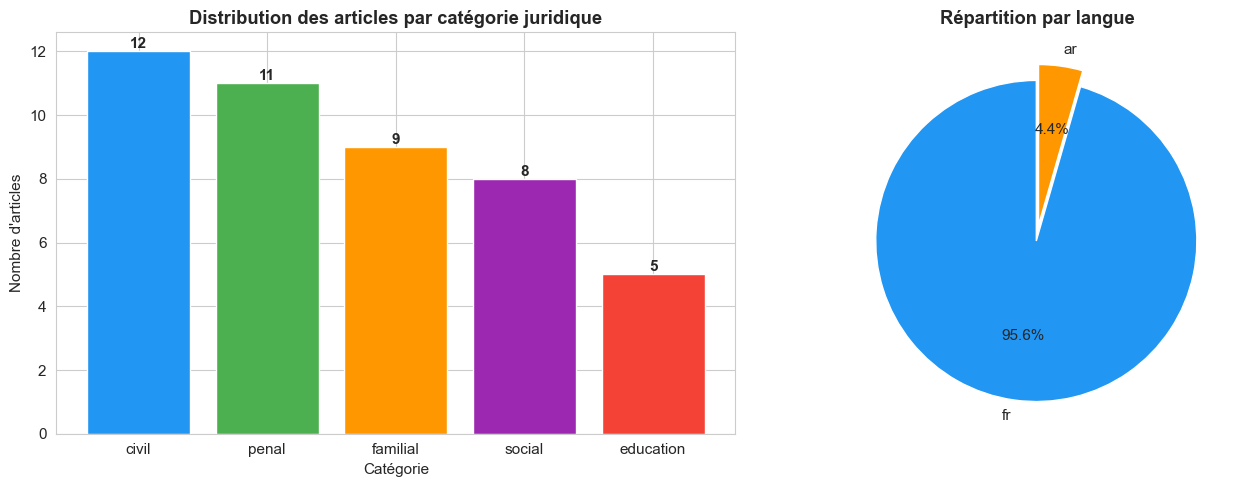

✅ Figure sauvegardée


In [24]:
# ============================================================
#  CELLULE 9 — Distribution des articles par catégorie
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : Articles par catégorie
cat_counts = df_proc['category'].value_counts()
colors = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336','#00BCD4']
axes[0].bar(cat_counts.index, cat_counts.values, color=colors[:len(cat_counts)])
axes[0].set_title('Distribution des articles par catégorie juridique', fontweight='bold')
axes[0].set_xlabel('Catégorie')
axes[0].set_ylabel('Nombre d\'articles')
for i, v in enumerate(cat_counts.values):
    axes[0].text(i, v + 0.1, str(v), ha='center', fontweight='bold')

# Graphique 2 : Répartition par langue
lang_counts = df_proc['language'].value_counts()
axes[1].pie(lang_counts.values, labels=lang_counts.index,
            autopct='%1.1f%%', colors=['#2196F3','#FF9800'],
            startangle=90, explode=[0.05]*len(lang_counts))
axes[1].set_title('Répartition par langue', fontweight='bold')

plt.tight_layout()
plt.savefig('../processed_data/fig_category_lang.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure sauvegardée')

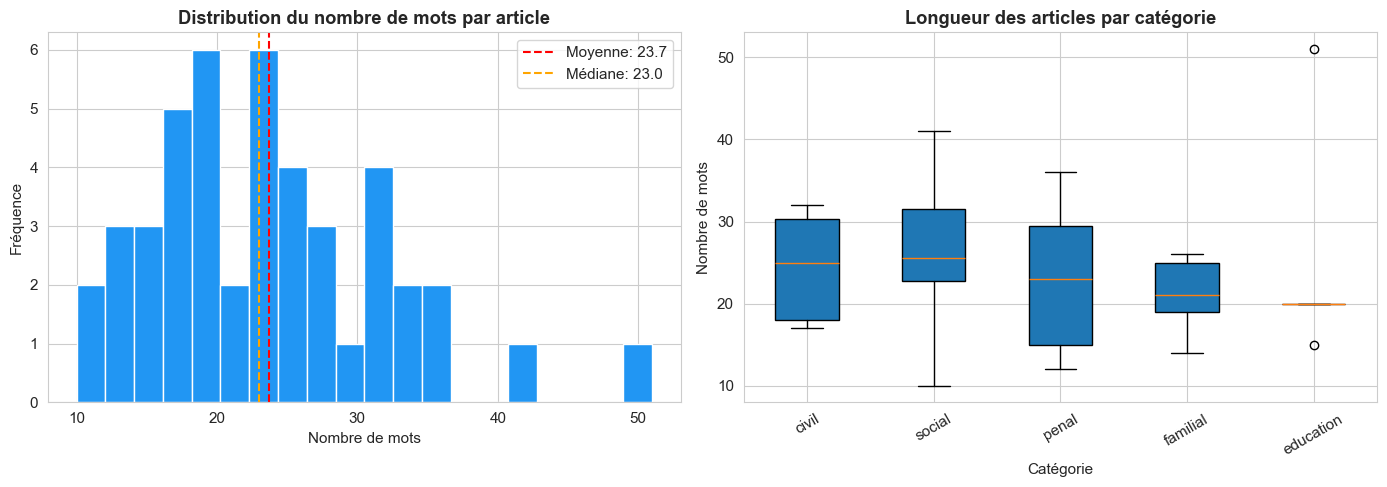

In [25]:
# ============================================================
#  CELLULE 10 — Distribution de la longueur des articles
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme des longueurs
axes[0].hist(df_proc['word_count'], bins=20, color='#2196F3', edgecolor='white')
axes[0].axvline(df_proc['word_count'].mean(), color='red', linestyle='--',
               label=f'Moyenne: {df_proc["word_count"].mean():.1f}')
axes[0].axvline(df_proc['word_count'].median(), color='orange', linestyle='--',
               label=f'Médiane: {df_proc["word_count"].median():.1f}')
axes[0].set_title('Distribution du nombre de mots par article', fontweight='bold')
axes[0].set_xlabel('Nombre de mots')
axes[0].set_ylabel('Fréquence')
axes[0].legend()

# Boxplot par catégorie
data_by_cat = [df_proc[df_proc['category']==c]['word_count'].values
               for c in df_proc['category'].unique()]
axes[1].boxplot(data_by_cat, labels=df_proc['category'].unique(), patch_artist=True)
axes[1].set_title('Longueur des articles par catégorie', fontweight='bold')
axes[1].set_xlabel('Catégorie')
axes[1].set_ylabel('Nombre de mots')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../processed_data/fig_word_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

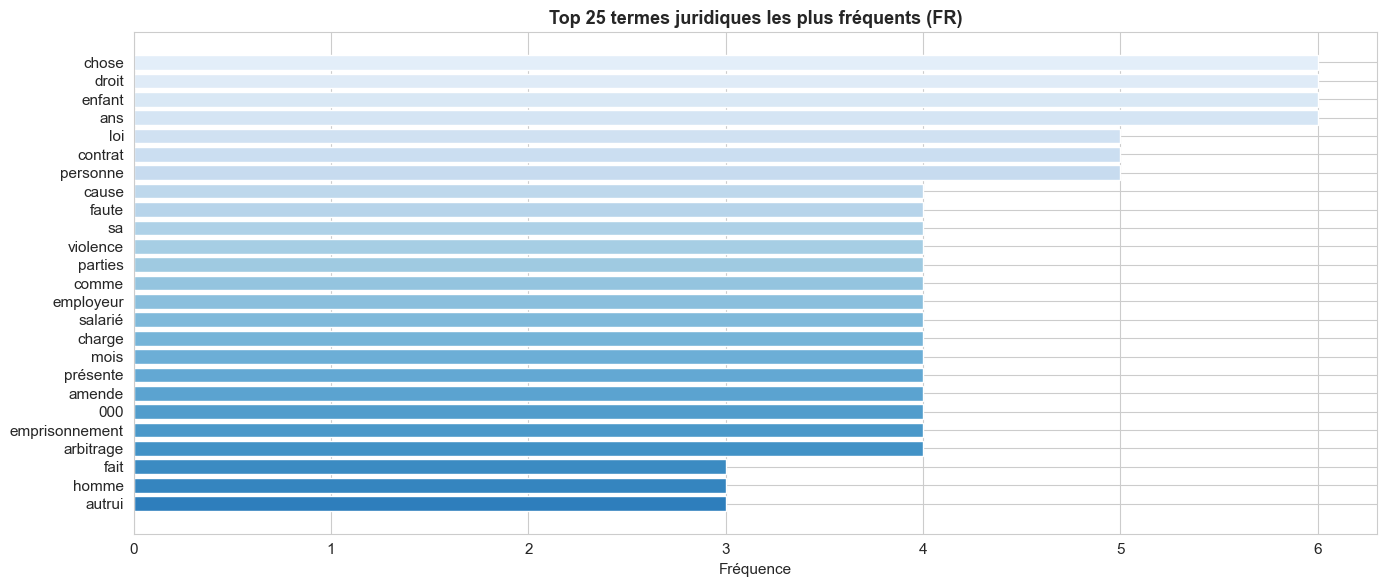

In [26]:
# ============================================================
#  CELLULE 11 — Top mots-clés juridiques les plus fréquents
# ============================================================
from collections import Counter

all_tokens_fr = []
for _, row in df_proc[df_proc['lang_detected']=='fr'].iterrows():
    all_tokens_fr.extend(row['tokens_no_sw'])

top_words = Counter(all_tokens_fr).most_common(25)
words, freqs = zip(*top_words)

plt.figure(figsize=(14, 6))
bars = plt.barh(list(words)[::-1], list(freqs)[::-1], color=plt.cm.Blues_r(
    np.linspace(0.3, 0.9, 25)))
plt.title('Top 25 termes juridiques les plus fréquents (FR)', fontweight='bold', fontsize=13)
plt.xlabel('Fréquence')
plt.tight_layout()
plt.savefig('../processed_data/fig_top_terms.png', dpi=150, bbox_inches='tight')
plt.show()

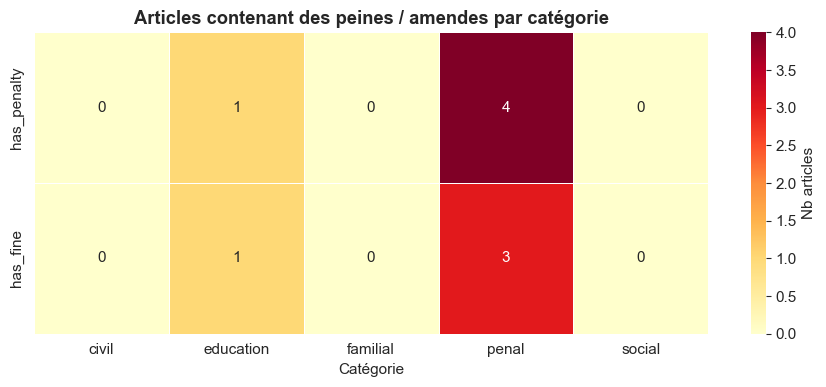

In [27]:
# ============================================================
#  CELLULE 12 — Heatmap articles avec peine / amende
# ============================================================
penalty_by_cat = df_proc.groupby('category')[['has_penalty','has_fine']].sum()

plt.figure(figsize=(9, 4))
sns.heatmap(penalty_by_cat.T, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Nb articles'})
plt.title('Articles contenant des peines / amendes par catégorie', fontweight='bold')
plt.xlabel('Catégorie')
plt.tight_layout()
plt.savefig('../processed_data/fig_penalty_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Export des données traitées

In [28]:
# ============================================================
#  CELLULE 13 — Export processed_laws.csv
# ============================================================
export_cols = [
    'id','source_file','category','subcategory','law_number',
    'title','article_number','article_text','article_text_clean',
    'language','lang_detected','date_promulgation',
    'text_length','word_count','token_count','content_token_count',
    'tokens_str','legal_keywords','has_penalty','has_fine',
    'referenced_articles'
]

# Ne garder que les colonnes qui existent
export_cols = [c for c in export_cols if c in df_proc.columns]

df_export = df_proc[export_cols].copy()

# Sauvegarder dans les deux emplacements
df_export.to_csv('../processed_data/processed_laws.csv', index=False, encoding='utf-8-sig')
df_export.to_csv('../processed_laws.csv', index=False, encoding='utf-8-sig')

print('✅ Fichiers sauvegardés :')
print('   • processed_data/processed_laws.csv')
print('   • processed_laws.csv  (racine du projet)')
print(f'\n📊 Résumé final :')
print(f'   Articles traités : {len(df_export)}')
print(f'   Lois couvertes   : {df_export["law_number"].nunique()}')
print(f'   Catégories       : {df_export["category"].nunique()}')
print(f'   Langues          : {df_export["lang_detected"].nunique()}')
print()
print(df_export.describe(include='all').T.to_string())

✅ Fichiers sauvegardés :
   • processed_data/processed_laws.csv
   • processed_laws.csv  (racine du projet)

📊 Résumé final :
   Articles traités : 45
   Lois couvertes   : 13
   Catégories       : 5
   Langues          : 2

                    count unique                                                                                                                              top freq        mean         std   min    25%    50%    75%    max
id                   45.0    NaN                                                                                                                              NaN  NaN        23.0   13.133926   1.0   12.0   23.0   34.0   45.0
source_file            45     14                                                                                             Code_des_Obligations_et_des_Contrats    8         NaN         NaN   NaN    NaN    NaN    NaN    NaN
category               45      5                                                                    